In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing


In [7]:
df= pd.read_csv('train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format = '%d/%m/%Y')

In [11]:
monthly_sales = df.groupby(pd.Grouper(key= 'Order Date', freq = 'ME'))['Sales'].sum()
monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

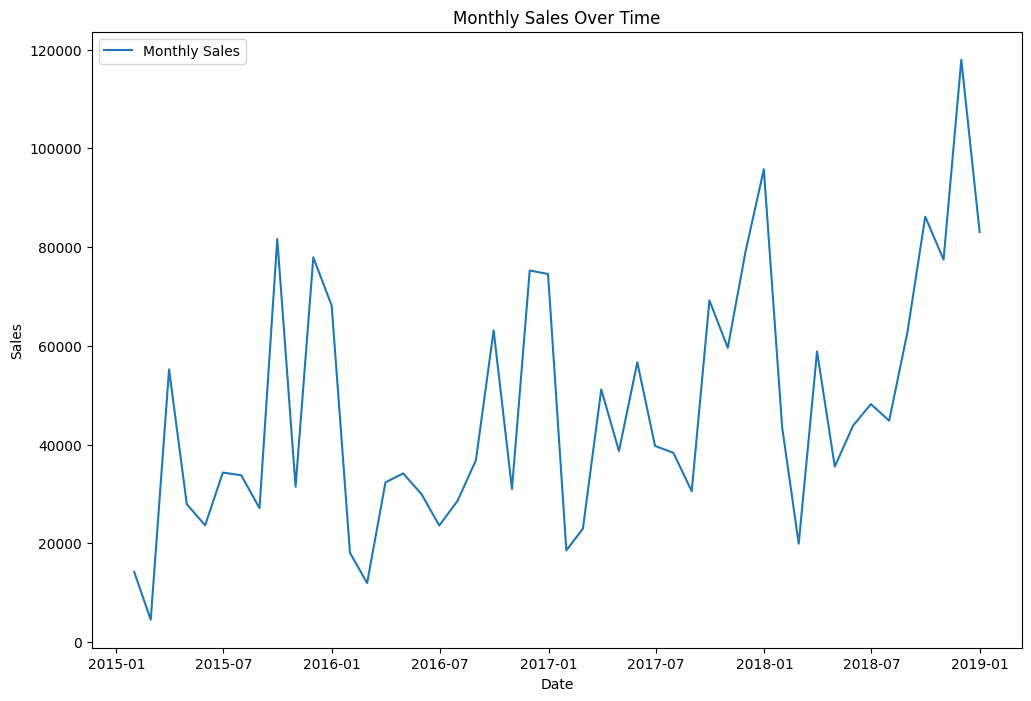

In [14]:
plt.figure(figsize=(12,8))
plt.plot(monthly_sales, label = "Monthly Sales")
plt.title('Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

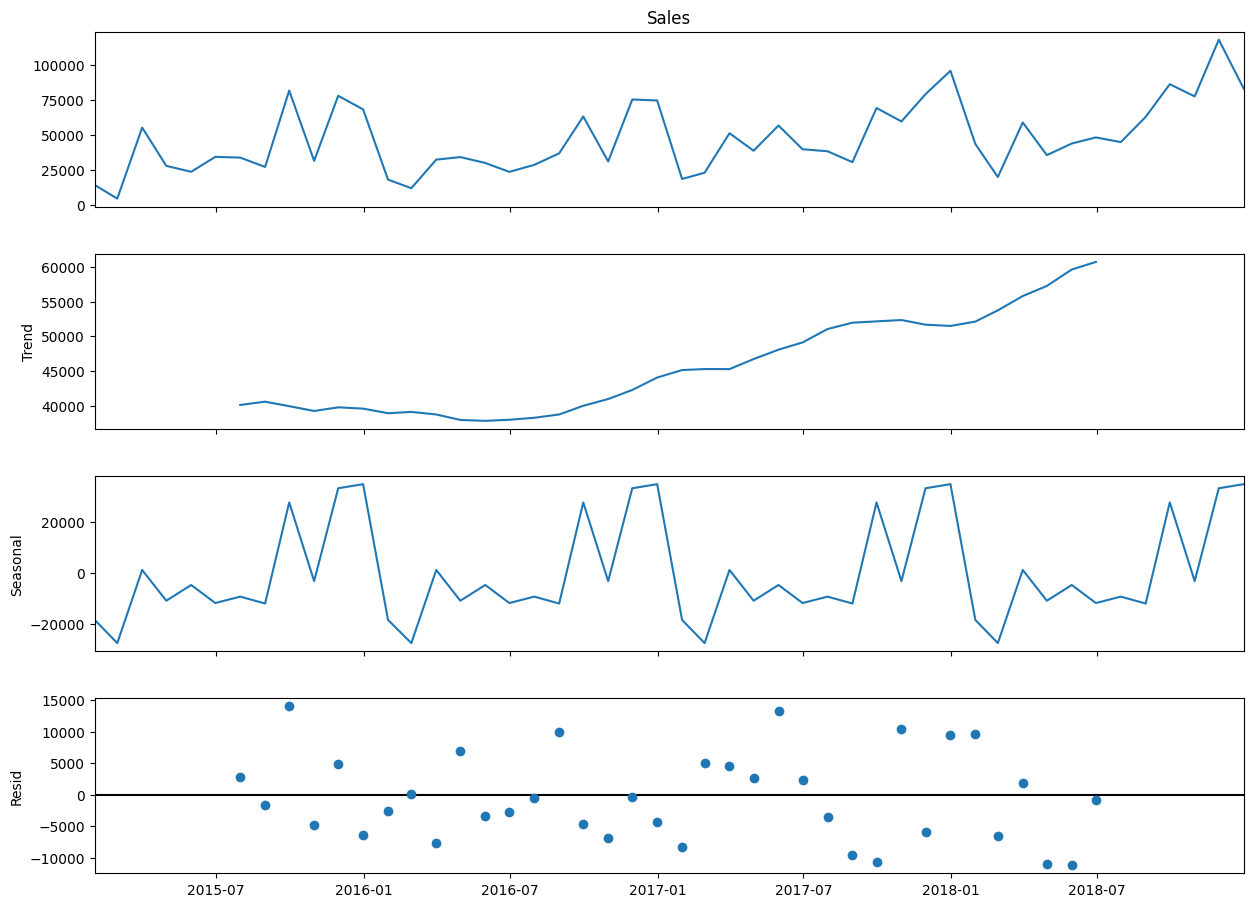

In [15]:
decompostion = seasonal_decompose(monthly_sales, model='additive')
fig = decompostion.plot()
fig.set_size_inches(14,10)
plt.show()

In [16]:
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('Augmented Dickey-Fuller Test Results')
    print('ADF Statistic: ', result[0])
    print('P-Value', result[1])
    print('Critical Values: ')
    for key, value in result[4].items():
        print(f'\t, {key}, {value}')
    return result[1] < .05

is_stationary = check_stationarity(monthly_sales)
print(f"\nTime series is {'stationary' if is_stationary else 'non-stationary'}")


Augmented Dickey-Fuller Test Results
ADF Statistic:  -4.416136761430769
P-Value 0.00027791039276670623
Critical Values: 
	, 1%, -3.5778480370438146
	, 5%, -2.925338105429433
	, 10%, -2.6007735310095064

Time series is stationary


In [18]:
auto_model = auto_arima(monthly_sales,
                        start_p = 0, start_q = 0,
                        max_p = 5, max_q = 5,
                        m =12,
                        seasonal = True,
                        d=None,
                        trace=True,
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=1085.632, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1096.560, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1076.500, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1077.487, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1094.708, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1089.579, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=1078.250, Time=0.08 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1078.452, Time=0.06 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1080.901, Time=0.04 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=1079.864, Time=0.13 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=1084.035, Time=0.03 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=1073.635, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1087.151, Time=0.02 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=1075.267, Time=0.09 sec
 ARIMA(2,1,0)(1,0,1

In [21]:
model = ARIMA(monthly_sales,
              order=auto_model.order,
              seasonal_order = auto_model.seasonal_order)
results = model.fit()

In [23]:
forecast_period = 12
forecast = results.get_forecast(steps=forecast_period)
mean_forecast = forecast.predicted_mean

In [26]:
conf_int_95 = forecast.conf_int(alpha=.05)
conf_int_80 = forecast.conf_int(alpha=.2)
conf_int_70 = forecast.conf_int(alpha=.3)

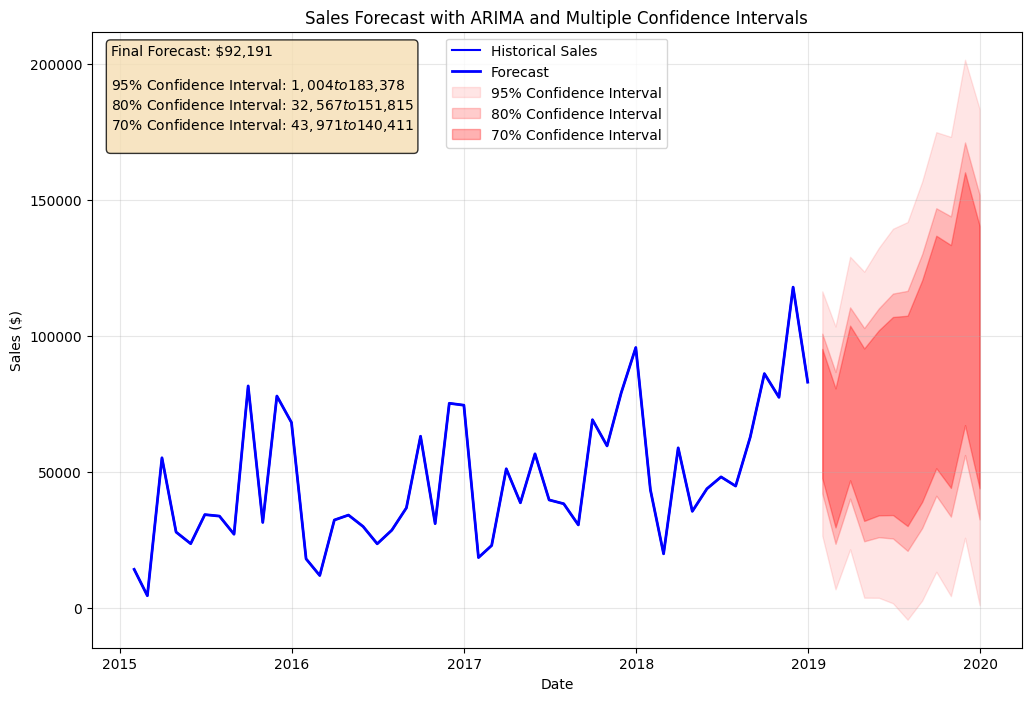

In [40]:
plt.figure(figsize=(12,8))

plt.plot(monthly_sales, label = "Historical Sales",color = 'blue')
plt.plot(monthly_sales, label = "Forecast", color = 'blue', linewidth = 2)

plt.fill_between(mean_forecast.index,
                 conf_int_95.iloc[:,0],
                 conf_int_95.iloc[:,1],
                 color = 'red', alpha =.1,
                 label = "95% Confidence Interval")
plt.fill_between(mean_forecast.index,
                 conf_int_80.iloc[:,0],
                 conf_int_80.iloc[:,1],
                 color = 'red', alpha =.2,
                 label = "80% Confidence Interval")
plt.fill_between(mean_forecast.index,
                 conf_int_70.iloc[:,0],
                 conf_int_70.iloc[:,1],
                 color = 'red', alpha =.3,
                 label = "70% Confidence Interval")

plt.title('Sales Forecast with ARIMA and Multiple Confidence Intervals')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha = .3)

last_forecast = mean_forecast.iloc[-1]

ranges_95_lower = conf_int_95.iloc[-1,0]
ranges_95_upper = conf_int_95.iloc[-1,1]
ranges_80_lower = conf_int_80.iloc[-1,0]
ranges_80_upper = conf_int_80.iloc[-1,1]
ranges_70_lower = conf_int_70.iloc[-1,0]
ranges_70_upper = conf_int_70.iloc[-1,1]

info_text = f'Final Forecast: ${last_forecast:,.0f}\n\n' \
            f'95% Confidence Interval: ${ranges_95_lower:,.0f} to ${ranges_95_upper:,.0f}\n' \
            f'80% Confidence Interval: ${ranges_80_lower:,.0f} to ${ranges_80_upper:,.0f}\n' \
            f'70% Confidence Interval: ${ranges_70_lower:,.0f} to ${ranges_70_upper:,.0f}\n'
plt.text(0.02,.98,info_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=.8))
plt.show()

In [41]:
print("\nModel Performance Metrics")

mse = mean_squared_error(monthly_sales, results.fittedvalues)
rmse = np.sqrt(mse)
mae = mean_absolute_error(monthly_sales, results.fittedvalues)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

print("Forecast Ranges for Final Period")
print(f"Point Forecast Range: {last_forecast:,.2f}")
print("\nConfidence Intervals")

print(f"95% CI: {ranges_95_lower:,.2f} to {ranges_95_upper:,.2f}")
print(f"80% CI: {ranges_80_lower:,.2f} to {ranges_80_upper:,.2f}")
print(f"70% CI: {ranges_70_lower:,.2f} to {ranges_70_upper:,.2f}")

print("\nInterval Widths as Percentage Forecast:")

print(f"95% CI: +-{((ranges_95_upper-ranges_95_lower)/2/last_forecast*100):.1f}%")
print(f"80% CI: +-{((ranges_80_upper-ranges_80_lower)/2/last_forecast*100):.1f}%")
print(f"70% CI: +-{((ranges_70_upper-ranges_70_lower)/2/last_forecast*100):.1f}%")

forecast_df = pd.DataFrame({
    'Forecast': mean_forecast,
    '95% Lower': conf_int_95.iloc[:,0],
    '95% Upper': conf_int_95.iloc[:,1],
    '80% Lower': conf_int_80.iloc[:,0],
    '80% Upper': conf_int_80.iloc[:,1],
    '70% Lower': conf_int_70.iloc[:,0],
    '70% Upper': conf_int_70.iloc[:,1],})
print("\nDetailed Forecast with Confidence Intervals")
print(forecast_df)


Model Performance Metrics
Mean Squared Error: 372198461.37
Root Mean Squared Error: 19292.45
Mean Absolute Error: 14432.38
Forecast Ranges for Final Period
Point Forecast Range: 92,191.07

Confidence Intervals
95% CI: 1,003.72 to 183,378.42
80% CI: 32,566.87 to 151,815.28
70% CI: 43,970.99 to 140,411.15

Interval Widths as Percentage Forecast:
95% CI: +-98.9%
80% CI: +-64.7%
70% CI: +-52.3%

Detailed Forecast with Confidence Intervals
                 Forecast     95% Lower      95% Upper     80% Lower  \
2019-01-31   71457.294750  26519.448465  116395.141035  42074.016428   
2019-02-28   55170.675645   6856.399001  103484.952290  23579.668178   
2019-03-31   75354.273325  21594.176473  129114.370177  40202.435420   
2019-04-30   63712.967911   3787.033020  123638.902802  24529.505214   
2019-05-31   68065.122532   3753.333455  132376.911608  26013.903926   
2019-06-30   70562.386126   1722.863561  139401.908691  25550.641721   
2019-07-31   68781.958274  -4308.035990  141871.952537  

In [42]:
models = []
specifications = [
    {
        'name': 'Fixed Parameters',
        'model': ExponentialSmoothing(
            monthly_sales,
            seasonal_periods=12,
            trend = 'add',
            seasonal = 'add',
            damped_trend = True
        ).fit(
            smoothing_level = .2,
            smoothing_trend = .1,
            smoothing_seasonal = .1,
            damping_trend = .98,
            optimized = False
        )
    },
    {
        'name': 'Multiplicative Seasonal',
        'model': ExponentialSmoothing(
            monthly_sales,
            seasonal_periods=12,
            trend = 'add',
            seasonal = 'mul',
            damped_trend = True
        ).fit(
            smoothing_level = .2,
            smoothing_trend = .1,
            smoothing_seasonal = .1,
            damping_trend = .98,
            optimized = False
        )
    },
    {
        'name': 'Multiplicative Trend',
        'model': ExponentialSmoothing(
            monthly_sales,
            seasonal_periods=12,
            trend = 'mul',
            seasonal = 'add',
            damped_trend = True
        ).fit(
            smoothing_level = .2,
            smoothing_trend = .1,
            smoothing_seasonal = .1,
            damping_trend = .98,
            optimized = False
        )
    }
]


In [43]:
results = []
for spec in specifications:
    model = spec['model']
    name  = spec['name']

    rmse = np.sqrt(mean_squared_error(monthly_sales, model.fittedvalues))
    mae = mean_absolute_error(monthly_sales, model.fittedvalues)

    results.append({
        'name': name,
        'rmse': rmse,
        'mae': mae,
        'model': model,
    })



In [45]:
best_model = min(results, key = lambda x: x['rmse'])

hw_model = best_model['model']
hw_forecast = hw_model.forecast(12)

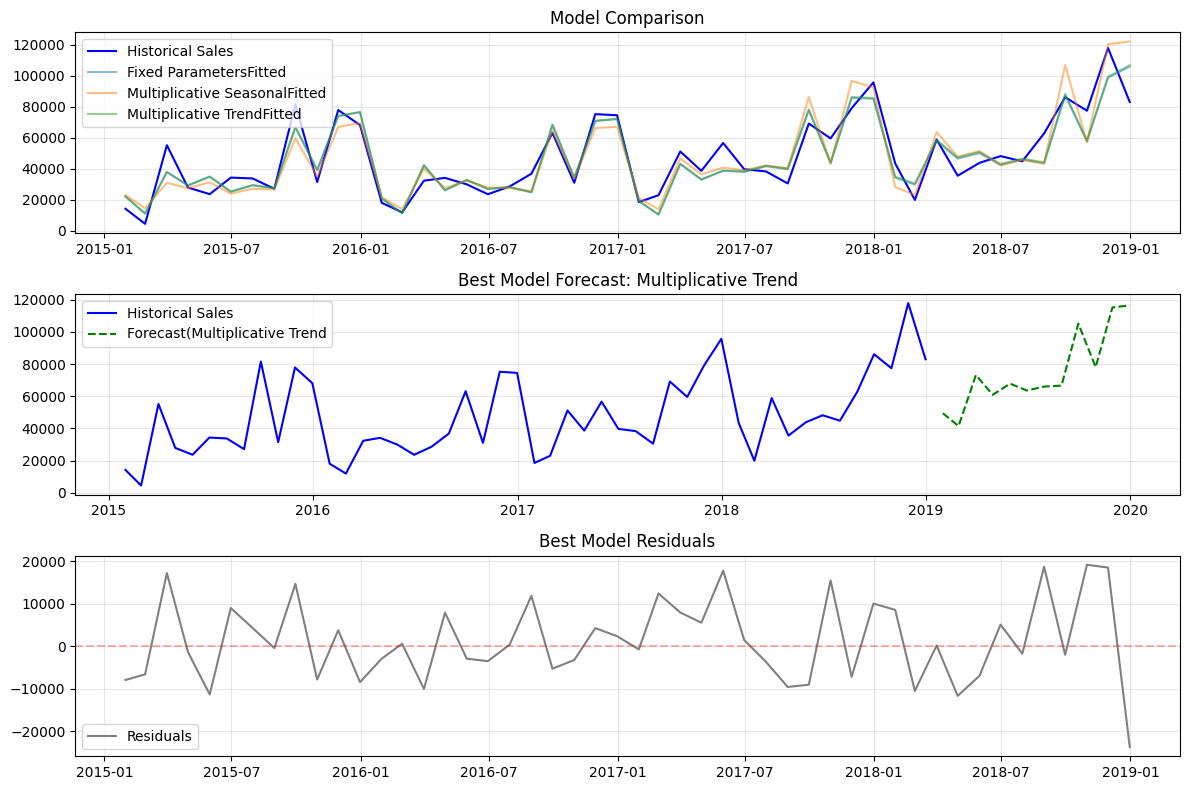

In [50]:
plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(monthly_sales.index,monthly_sales, label  = "Historical Sales",color = 'blue')

for result in results:
    plt.plot(result['model'].fittedvalues.index,
             result['model'].fittedvalues,
             label = f"{result["name"]}Fitted",
             alpha = .5)
plt.title("Model Comparison")
plt.legend()
plt.grid(True, alpha = .3)

plt.subplot(3,1,2)
plt.plot(monthly_sales.index,monthly_sales, label  = "Historical Sales",color = 'blue')

plt.plot(hw_forecast.index,hw_forecast,
         label = f"Forecast({best_model["name"]}",color = 'green',
         linestyle = '--')

plt.title(f"Best Model Forecast: {best_model["name"]}")
plt.legend()
plt.grid(True, alpha = .3)

plt.subplot(3,1,3)
residuals = monthly_sales - hw_model.fittedvalues
plt.plot(monthly_sales.index,residuals, label = "Residuals",color = 'gray')
plt.axhline(y=0, color = 'red', linestyle = '--', alpha=.3)
plt.title("Best Model Residuals")
plt.legend()
plt.grid(True, alpha = .3)

plt.tight_layout()
plt.show()

In [52]:
print("\nModel Comparison:")
for result in results:
    print(f"\n{result['name']}:")
    print(f"RMSE: {result['rmse']}")
    print(f"MAE: {result['mae']}")
print(f"\nBest Model: {best_model['name']}")
print(f"Best RMSE: ${best_model['rmse']:.2f}")


Model Comparison:

Fixed Parameters:
RMSE: 9783.597250630219
MAE: 7831.269048033438

Multiplicative Seasonal:
RMSE: 11758.669672436303
MAE: 8762.041257003448

Multiplicative Trend:
RMSE: 9762.290924720162
MAE: 7841.89557727872

Best Model: Multiplicative Trend
Best RMSE: $9762.29


In [55]:
print("\nBest Model Parameters:")
print(f"- Smoothing Level (a): {hw_model.params['smoothing_level']:.3f}")
print(f"- Trend Smoothing (b): {hw_model.params['smoothing_trend']:.3f}")
print(f"- Seasonal Smoothing (c): {hw_model.params['smoothing_seasonal']:.3f}")
print(f"- Daming Parameter (d): {hw_model.params['damping_trend']:.3f}")



Best Model Parameters:
- Smoothing Level (a): 0.200
- Trend Smoothing (b): 0.100
- Seasonal Smoothing (c): 0.100
- Daming Parameter (d): 0.980


In [56]:
hw_forecast

2019-01-31     49435.711479
2019-02-28     41459.506838
2019-03-31     73220.555712
2019-04-30     60904.078997
2019-05-31     67886.536597
2019-06-30     63574.157506
2019-07-31     66020.931715
2019-08-31     66663.177848
2019-09-30    105201.488326
2019-10-31     78140.769889
2019-11-30    115255.953319
2019-12-31    116513.155267
Freq: ME, dtype: float64

In [58]:
final_results = pd.DataFrame({
    'Actual': monthly_sales,
    'Predicted': hw_model.fittedvalues,
    'Residuals': residuals
})
print(final_results)

                 Actual      Predicted     Residuals
Order Date                                          
2015-01-31   14205.7070   22155.386037  -7949.679037
2015-02-28    4519.8920   11146.811114  -6626.919114
2015-03-31   55205.7970   37975.018760  17230.778240
2015-04-30   27906.8550   29267.192066  -1360.337066
2015-05-31   23644.3030   35011.240872 -11366.937872
2015-06-30   34322.9356   25323.862069   8999.073531
2015-07-31   33781.5430   29471.746667   4309.796333
2015-08-31   27117.5365   27556.862748   -439.326248
2015-09-30   81623.5268   66942.870651  14680.656149
2015-10-31   31453.3930   39306.677895  -7853.284895
2015-11-30   77907.6607   74133.215819   3774.444881
2015-12-31   68167.0585   76624.430323  -8457.371823
2016-01-31   18066.9576   20970.723747  -2903.766147
2016-02-29   11951.4110   11372.983261    578.427739
2016-03-31   32339.3184   42412.453053 -10073.134653
2016-04-30   34154.4685   26249.677779   7904.790721
2016-05-31   29959.5305   32890.486634  -2930.